In [24]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.transform import resize
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

In [13]:
df = pd.read_pickle("../project/Dataset.pkl")
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [14]:
def clean_nested_columns(df):
    # Rename the column with the original typo
    if 'trianTestLabel' in df.columns:
        df.rename(columns={'trianTestLabel': 'trainTestLabel'}, inplace=True)
    
    # Inner function to extract and format text
    def extract_text(value):
        while isinstance(value, (np.ndarray, list)):
            if len(value) == 0:
                return "unknown"
            value = value[0]
        
        # Return the clean string in lowercase (e.g., 'none', 'training', 'center')
        return str(value).lower()
    
    # Apply cleaning to label columns
    columns_to_fix = ['trainTestLabel', 'failureType']
    
    for col in columns_to_fix:
        if col in df.columns:
            df[col] = df[col].apply(extract_text)
            
    return df

df = clean_nested_columns(df)
df.head()

,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,training,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,training,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,training,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,training,none


# Wafer shapes

In [15]:
wafer_shapes = df['waferMap'].apply(lambda x: x.shape)
shape_counts = wafer_shapes.value_counts()
print(shape_counts)

print("\nTotal number of different shapes:")
print(len(shape_counts))

waferMap
(25, 27)     18781
(26, 26)     14366
(30, 34)     12400
(29, 26)     11751
(27, 25)     10682
             ...  
(68, 72)         1
(29, 45)         1
(38, 62)         1
(43, 133)        1
(36, 41)         1
Name: count, Length: 346, dtype: int64

Total number of different shapes:
346


In [16]:
def resize_wafer_maps(df, target_shape=(56, 56)):
    print(f"Ridimensionamento delle mappe dei wafer a {target_shape}...")
    
    resized_maps = []
    
    # Usiamo tqdm per vedere la barra di avanzamento
    for i in tqdm(range(len(df))):
        img = df['waferMap'].iloc[i]
        
        # Ridimensioniamo la matrice. 
        # order=0 indica un'interpolazione "nearest-neighbor", fondamentale per dati discreti 
        # (0, 1, 2) perché evita di creare sfumature con numeri decimali.
        img_resized = resize(img, target_shape, order=0, preserve_range=True, anti_aliasing=False)
        
        resized_maps.append(img_resized.astype(np.uint8))
        
    # Creiamo un unico grande array NumPy di forma (N_immagini, Altezza, Larghezza)
    X = np.array(resized_maps)
    
    # Aggiungiamo la dimensione del canale (1 per scala di grigi) richiesta dalle CNN
    X = np.expand_dims(X, axis=-1)
    
    return X

# Esegui il ridimensionamento (puoi scegliere 56x56 o 64x64 per un buon compromesso velocità/dettaglio)
X = resize_wafer_maps(df, target_shape=(56, 56))

print(f"\nFormato finale del tensore di input per la CNN: {X.shape}")

Ridimensionamento delle mappe dei wafer a (56, 56)...


100%|██████████| 172950/172950 [00:12<00:00, 13440.56it/s]



Formato finale del tensore di input per la CNN: (172950, 56, 56, 1)


# Label encoding

In [17]:
encoder = LabelEncoder()
# Transform the text column into a numeric array (y)
y = encoder.fit_transform(df['failureType'])

print(f"Encoded classes: {encoder.classes_}\n")

Encoded classes: ['center' 'donut' 'edge-loc' 'edge-ring' 'loc' 'near-full' 'none' 'random'
 'scratch']



# Balanced Undersampling (Capping) for ALL classes

In [18]:
MAX_SAMPLES_PER_CLASS = 3000
balanced_indices = []

np.random.seed(42) # For reproducibility

# Iterate through each unique class found in the dataset
for class_value in np.unique(y):
    # Find all indices belonging to this specific class
    class_indices = np.where(y == class_value)[0]
    
    # If the class has more images than our limit...
    if len(class_indices) > MAX_SAMPLES_PER_CLASS:
        # Randomly sample only MAX_SAMPLES_PER_CLASS
        sampled_indices = np.random.choice(class_indices, size=MAX_SAMPLES_PER_CLASS, replace=False)
    else:
        # If it has fewer (e.g., near-full), keep all of them
        sampled_indices = class_indices
        
    # Add these indices to our global list
    balanced_indices.extend(sampled_indices)

# Convert the list to a NumPy array
balanced_indices = np.array(balanced_indices)

# Randomly shuffle the new dataset to avoid ordered blocks
np.random.shuffle(balanced_indices)

# Creation of final balanced tensors

In [19]:
X_balanced = X[balanced_indices]
y_balanced = y[balanced_indices]

print("\n--- Dataset Ready and Perfectly Balanced ---")
print(f"X_balanced shape: {X_balanced.shape}")
print(f"y_balanced shape: {y_balanced.shape}")

# (Optional) Print the new distribution for confirmation
unique, counts = np.unique(y_balanced, return_counts=True)
print("\nNew class distribution:")
for u, c in zip(unique, counts):
    print(f"{encoder.inverse_transform([u])[0]}: {c}")


--- Dataset Ready and Perfectly Balanced ---
X_balanced shape: (17763, 56, 56, 1)
y_balanced shape: (17763,)

New class distribution:
center: 3000
donut: 555
edge-loc: 3000
edge-ring: 3000
loc: 3000
near-full: 149
none: 3000
random: 866
scratch: 1193


In [20]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 1. Pixel Normalization
# Neural networks converge much faster and are more stable with values between 0 and 1
print("Normalizing pixel values...")
X_normalized = X_balanced.astype('float32') / 255.0

# 2. Train, Validation, and Test Split
# We use 'stratify' to ensure the class distribution remains consistent across all sets
# First split: 80% for Training, 20% for Validation/Test combined
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

# Second split: Divide the remaining 20% equally into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 3. One-Hot Encoding for Labels
# Convert integer labels (e.g., 2) into probability arrays (e.g., [0, 0, 1, 0, 0, 0, 0, 0, 0])
num_classes = len(np.unique(y_balanced))

y_train_categorical = to_categorical(y_train, num_classes=num_classes)
y_val_categorical = to_categorical(y_val, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)

print("\n--- Final Data Shapes ---")
print(f"Training set:   X: {X_train.shape}, y: {y_train_categorical.shape}")
print(f"Validation set: X: {X_val.shape}, y: {y_val_categorical.shape}")
print(f"Test set:       X: {X_test.shape}, y: {y_test_categorical.shape}")

Normalizing pixel values...

--- Final Data Shapes ---
Training set:   X: (14210, 56, 56, 1), y: (14210, 9)
Validation set: X: (1776, 56, 56, 1), y: (1776, 9)
Test set:       X: (1777, 56, 56, 1), y: (1777, 9)


In [ ]:
# 1. Define network parameters based on our preprocessed data
INPUT_SHAPE = (56, 56, 1)  # 56x56 pixels, 1 channel (grayscale)
NUM_CLASSES = 9            # Total number of defect categories

# 2. Initialize the Sequential model
model = Sequential(name="Wafer_Defect_CNN")

# --- Block 1: Feature Extraction ---

# First Convolutional Block
# Extracts basic geometric features (edges, lines)
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=INPUT_SHAPE))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Convolutional Block
# Extracts more complex patterns (curves, small clusters)
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third Convolutional Block
# Extracts high-level concepts (full rings, donut shapes)
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# --- Block 2: Classification ---

# Flatten the 3D tensor into a 1D vector to feed the dense layers
model.add(Flatten())

# Hidden Fully Connected Layer
model.add(Dense(128, activation='relu'))
# Dropout randomly deactivates 50% of neurons to prevent overfitting
model.add(Dropout(0.5))

# Output Layer
# Softmax outputs a probability distribution across the 9 classes
model.add(Dense(NUM_CLASSES, activation='softmax'))

# 3. Compile the Model
# We use categorical_crossentropy because our labels are one-hot encoded
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print a table showing the network structure and number of parameters
model.summary()

c:\Users\lollo\anaconda3\envs\data_science\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Wafer_Defect_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,673 (3.42 MB)

 Trainable params: 897,225 (3.42 MB)

 Non-trainable params: 448 (1.75 KB)

# Training

Starting model training...
Epoch 1/50
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4217 - loss: 1.8894
Epoch 1: val_accuracy improved from None to 0.00845, saving model to best_wafer_cnn.keras
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.5156 - loss: 1.3650 - val_accuracy: 0.0084 - val_loss: 9.8156 - learning_rate: 0.0010
Epoch 2/50
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6514 - loss: 0.9623
Epoch 2: val_accuracy did not improve from 0.00845
223/223 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.6723 - loss: 0.9025 - val_accuracy: 0.0084 - val_loss: 16.4047 - learning_rate: 0.0010
Epoch 3/50
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7227 - loss: 0.7652
Epoch 3: val_accuracy improved from 0.00845 to 0.18581, saving model to best_wafer_cnn.keras
223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - accuracy: 0.7305 - loss: 0.7453 - val_accuracy: 0.1858 - val_loss: 5.0338 - learning_rate: 0.0010
Epoch 4/50
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/

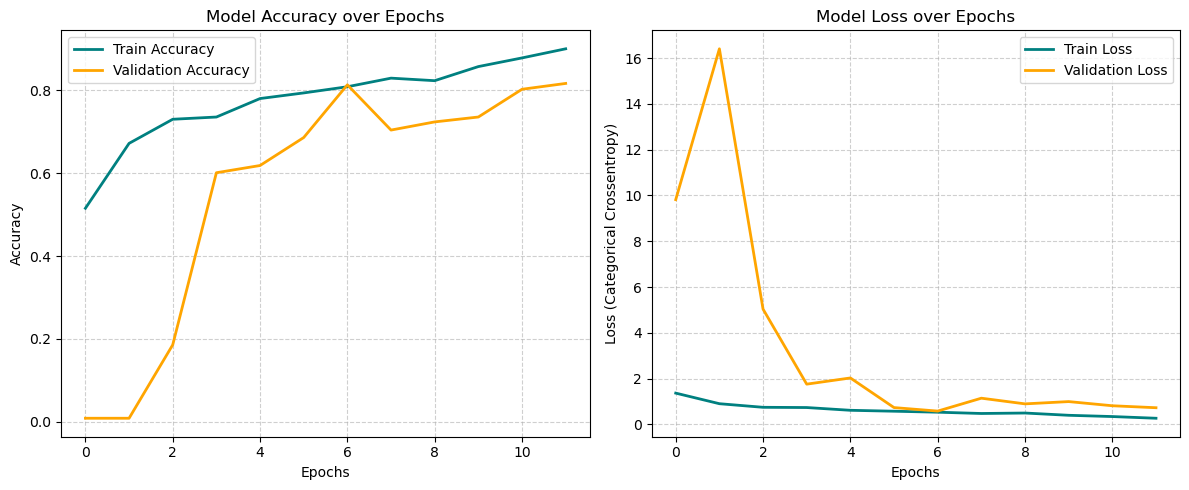

In [ ]:
# 1. Define Callbacks (The Supervisors)

# EarlyStopping: Stops training if validation loss doesn't improve for 5 consecutive epochs
# restore_best_weights=True ensures we keep the best version of the model, not the last one
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True, 
    verbose=1
)

# ReduceLROnPlateau: Slowly reduces the learning rate if the model gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

# ModelCheckpoint: Saves the physical file of the best model automatically
checkpoint = ModelCheckpoint(
    filepath='best_wafer_cnn.keras',
    monitor='val_accuracy', 
    save_best_only=True, 
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

# 2. Train the Model (The fit phase)
EPOCHS = 50       # Maximum number of iterations (EarlyStopping will likely stop it earlier)
BATCH_SIZE = 64   # How many images the network processes at once before updating weights

print("Starting model training...")
history = model.fit(
    X_train, 
    y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_categorical),
    callbacks=callbacks_list,
    verbose=1
)
print("Training completed!")

# 3. Plot the Training History
def plot_training_history(history):
    print("Plotting learning curves...")
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='teal', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
    plt.title('Model Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot Loss (Error)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='teal', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    plt.title('Model Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Categorical Crossentropy)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Execute the plotting function
plot_training_history(history)

# Test set

Evaluating model on Test Set...
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      center       0.91      0.93      0.92       300
       donut       0.96      0.78      0.86        55
    edge-loc       0.77      0.82      0.80       300
   edge-ring       0.98      0.92      0.95       300
         loc       0.71      0.62      0.66       300
   near-full       1.00      0.73      0.85        15
        none       0.64      0.96      0.77       300
      random       0.96      0.59      0.73        87
     scratch       0.52      0.23      0.32       120

    accuracy                           0.79      1777
   macro avg       0.83      0.73      0.76      1777
weighted avg       0.80      0.79      0.78      1777

Plotting Confusion Matrix...


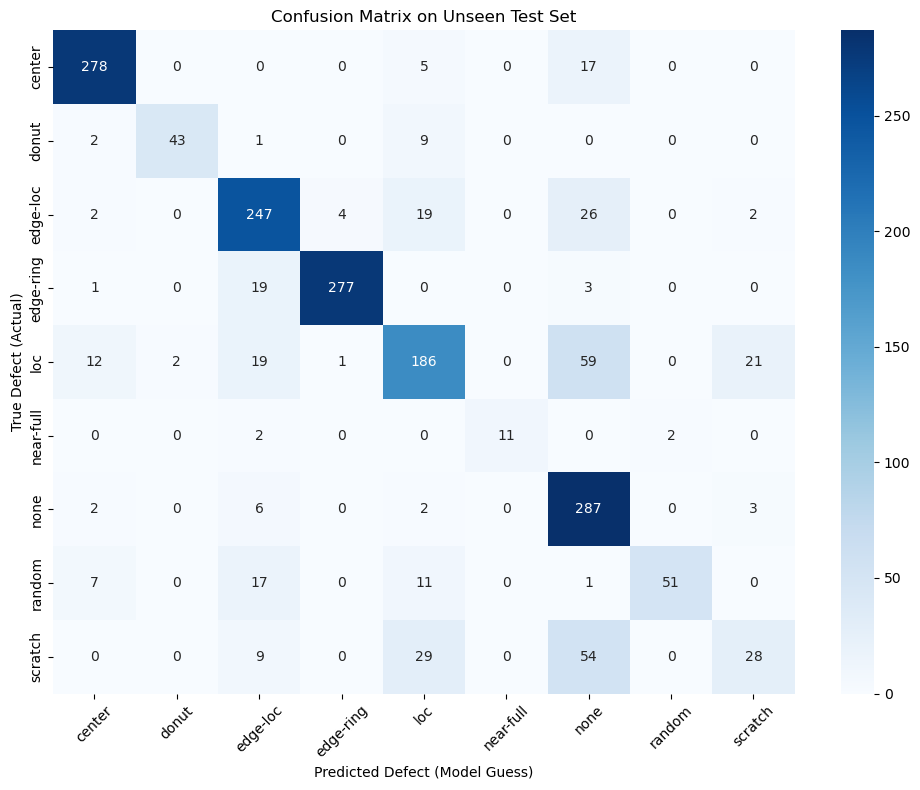

In [ ]:
# 1. Get model predictions on the unseen Test Set
print("Evaluating model on Test Set...")
y_pred_probs = model.predict(X_test)

# Convert probability arrays back to class integers 
# (e.g., [0.1, 0.8, 0.1, ...] becomes class index 1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
# We retrieve the actual text names of the defects from our encoder
class_names = encoder.classes_

print("\n--- Classification Report ---")
# This will show Precision, Recall, and F1-Score for each specific defect
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
# We use a heatmap to visually highlight where the model makes mistakes
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix on Unseen Test Set')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# TO-DO
### Comparare diversi optimizers (non solo adam)
### Cambiare l'Inizializzazione dei pesi (He Initialization)
### Implementare la data augmentation
### Aggiungere la regolarizzazione L2